In [2]:
import pandas as pd
import numpy as np
import pickle as pkl
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('customer_churn.csv',delimiter=';')

In [4]:
df.tail()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
440827,449995,42,Male,54.0,15,1.0,3,Premium,Annual,716.38,8,0
440828,449996,25,Female,8.0,13,1.0,20,Premium,Annual,745.38,2,0
440829,449997,26,Male,35.0,27,1.0,5,Standard,Quarterly,977.31,9,0
440830,449998,28,Male,55.0,14,2.0,0,Standard,Quarterly,602.55,2,0
440831,449999,31,Male,48.0,20,1.0,14,Premium,Quarterly,567.77,21,0


In [5]:
df.shape

(440832, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440832 entries, 0 to 440831
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  int64  
 1   Age                440832 non-null  int64  
 2   Gender             440821 non-null  object 
 3   Tenure             440820 non-null  float64
 4   Usage Frequency    440832 non-null  int64  
 5   Support Calls      440802 non-null  float64
 6   Payment Delay      440832 non-null  int64  
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440823 non-null  float64
 10  Last Interaction   440832 non-null  int64  
 11  Churn              440832 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 40.4+ MB


In [7]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

In [8]:
df.Churn.value_counts()

Churn
1    249999
0    190833
Name: count, dtype: int64

**Split Data into Train and Test Data**

In [9]:
input_df=df.drop(['Churn','CustomerID'],axis=1)
output_df=df['Churn']

In [10]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(input_df, output_df, test_size = 0.2, random_state = 42)

In [11]:
x_train.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
321744,24,Male,58.0,28,0.0,4,Basic,Annual,665.22,29
175119,24,Male,26.0,12,1.0,26,Basic,Quarterly,754.00,12
272447,18,Male,36.0,8,0.0,7,Premium,Quarterly,852.86,9
66769,36,Female,18.0,9,2.0,23,Premium,Monthly,758.00,3
70297,57,Female,27.0,26,8.0,15,Basic,Monthly,688.00,10


In [12]:
y_train.head()

321744    0
175119    1
272447    0
66769     1
70297     1
Name: Churn, dtype: int64

In [13]:
x_train.columns

Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend',
       'Last Interaction'],
      dtype='object')

In [14]:
x_train.shape

(352665, 10)

**Handle Missing Value**

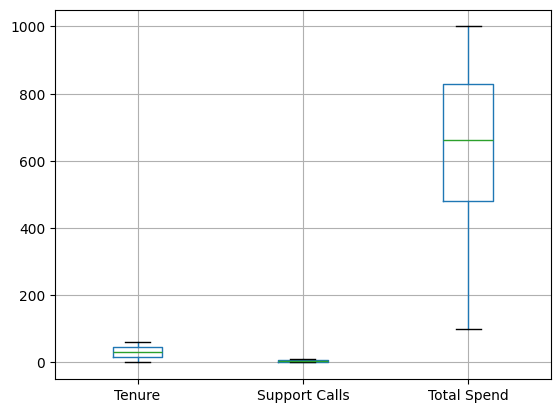

In [15]:
#Check Outliers
boxplot = x_train.boxplot(column=['Tenure','Support Calls','Total Spend'])
plt.show()

In [16]:
#Calculate Mean for Tenure,Support Calls,Total Spend
print('mean tenure:',np.mean(x_train['Tenure']))
print('mean Support Calls:',np.mean(x_train['Support Calls']))
print('mean Total Spend:',np.mean(x_train['Total Spend']))

mean tenure: 31.264970764545417
mean Support Calls: 3.6030886760831775
mean Total Spend: 631.5849042275967


In [17]:
#Impute missing value with mean for train and test
x_train['Tenure']= x_train['Tenure'].fillna(31.3)
x_train['Support Calls']=x_train['Support Calls'].fillna(4)
x_train['Total Spend']=x_train['Total Spend'].fillna(631.6)


x_test['Tenure']=x_test['Tenure'].fillna(31.3)
x_test['Support Calls']=x_test['Support Calls'].fillna(4)
x_test['Total Spend']=x_test['Total Spend'].fillna(631.6)


In [18]:
#Impute missing value with mode
x_train['Gender'] = x_train['Gender'].fillna(x_train['Gender'].mode()[0])
x_test['Gender']  = x_test['Gender'].fillna(x_train['Gender'].mode()[0])


In [19]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 352665 entries, 321744 to 121958
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Age                352665 non-null  int64  
 1   Gender             352665 non-null  object 
 2   Tenure             352665 non-null  float64
 3   Usage Frequency    352665 non-null  int64  
 4   Support Calls      352665 non-null  float64
 5   Payment Delay      352665 non-null  int64  
 6   Subscription Type  352665 non-null  object 
 7   Contract Length    352665 non-null  object 
 8   Total Spend        352665 non-null  float64
 9   Last Interaction   352665 non-null  int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 29.6+ MB


**Categorical Feature Encoding**

In [20]:
#Check value of features
df.Gender.value_counts()

Gender
Male      250245
Female    190576
Name: count, dtype: int64

In [21]:
df['Subscription Type'].value_counts()

Subscription Type
Standard    149128
Premium     148678
Basic       143026
Name: count, dtype: int64

In [22]:
df['Contract Length'].value_counts()

Contract Length
Annual       177198
Quarterly    176530
Monthly       87104
Name: count, dtype: int64

In [23]:
#Binary Encoding Categorical to integer
x_train = (x_train.replace({"Gender": {"Male": 1, "Female": 0}}))

x_test = (x_test.replace({"Gender": {"Male": 1, "Female": 0}}))

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25120\1456576591.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x_train = (x_train.replace({"Gender": {"Male": 1, "Female": 0}}))
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25120\1456576591.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x_test = (x_test.replace({"Gender": {"Male": 1, "Female": 0}}))


In [24]:
x_train.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
321744,24,1,58.0,28,0.0,4,Basic,Annual,665.22,29
175119,24,1,26.0,12,1.0,26,Basic,Quarterly,754.00,12
272447,18,1,36.0,8,0.0,7,Premium,Quarterly,852.86,9
66769,36,0,18.0,9,2.0,23,Premium,Monthly,758.00,3
70297,57,0,27.0,26,8.0,15,Basic,Monthly,688.00,10


In [25]:
x_train["Subscription Type"].value_counts()

Subscription Type
Standard    119101
Premium     119046
Basic       114518
Name: count, dtype: int64

In [26]:
#Ordinal Encoding
from sklearn.preprocessing import OrdinalEncoder

subs_categories = [['Basic', 'Standard', 'Premium']]
cont_categories = [['Monthly', 'Quarterly', 'Annual']]

subs_enc_train=x_train[['Subscription Type']]
cont_enc_train=x_train[['Contract Length']]

subs_enc_test=x_test[['Subscription Type']]
cont_enc_test=x_test[['Contract Length']]

subs_encoder = OrdinalEncoder(categories=subs_categories,handle_unknown='use_encoded_value',unknown_value=-1)
cont_encoder = OrdinalEncoder(categories=cont_categories,handle_unknown='use_encoded_value',unknown_value=-1)

subs_train_encoded = subs_encoder.fit_transform(subs_enc_train)
cont_train_encoded = cont_encoder.fit_transform(cont_enc_train)

subs_test_encoded = subs_encoder.transform(subs_enc_test)
cont_test_encoded = cont_encoder.transform(cont_enc_test)

subs_train_encoded = pd.DataFrame(subs_train_encoded,columns=['Subscription Type Ordinal'])
cont_train_encoded = pd.DataFrame(cont_train_encoded,columns=['Contract Length Ordinal'])
subs_test_encoded = pd.DataFrame(subs_test_encoded,columns=['Subscription Type Ordinal'])
cont_test_encoded = pd.DataFrame(cont_test_encoded,columns=['Contract Length Ordinal'])


x_train = x_train.reset_index(drop=True)
x_test = x_test.reset_index(drop=True)

x_train_enc = pd.concat([x_train, subs_train_encoded, cont_train_encoded], axis=1)
x_test_enc = pd.concat([x_test, subs_test_encoded, cont_test_encoded], axis=1)


In [27]:
x_train_enc.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Subscription Type Ordinal,Contract Length Ordinal
0,24,1,58.0,28,0.0,4,Basic,Annual,665.22,29,0.0,2.0
1,24,1,26.0,12,1.0,26,Basic,Quarterly,754.00,12,0.0,1.0
2,18,1,36.0,8,0.0,7,Premium,Quarterly,852.86,9,2.0,1.0
3,36,0,18.0,9,2.0,23,Premium,Monthly,758.00,3,2.0,0.0
4,57,0,27.0,26,8.0,15,Basic,Monthly,688.00,10,0.0,0.0


In [28]:
x_test_enc.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Subscription Type Ordinal,Contract Length Ordinal
0,23,0,10.0,16,8.0,16,Premium,Quarterly,589.00,13,2.0,1.0
1,33,1,3.0,20,0.0,22,Basic,Quarterly,158.00,12,0.0,1.0
2,27,0,57.0,3,0.0,24,Standard,Annual,915.00,26,1.0,2.0
3,35,0,28.0,23,5.0,13,Basic,Annual,334.00,29,0.0,2.0
4,28,1,53.0,30,2.0,5,Basic,Annual,568.86,15,0.0,2.0


In [29]:
x_train_enc.columns

Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend',
       'Last Interaction', 'Subscription Type Ordinal',
       'Contract Length Ordinal'],
      dtype='object')

**Define the features for modelling**

In [30]:
x_train_enc=x_train_enc.drop(['Subscription Type', 'Contract Length'],axis=1)

In [31]:
x_train_enc.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Subscription Type Ordinal,Contract Length Ordinal
0,24,1,58.0,28,0.0,4,665.22,29,0.0,2.0
1,24,1,26.0,12,1.0,26,754.00,12,0.0,1.0
2,18,1,36.0,8,0.0,7,852.86,9,2.0,1.0
3,36,0,18.0,9,2.0,23,758.00,3,2.0,0.0
4,57,0,27.0,26,8.0,15,688.00,10,0.0,0.0


In [32]:
x_train_enc.columns

Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Total Spend', 'Last Interaction',
       'Subscription Type Ordinal', 'Contract Length Ordinal'],
      dtype='object')

In [33]:
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

RF_class = RandomForestClassifier(criterion= 'gini',max_depth=4)
rf=RF_class.fit(x_train_enc, y_train)


In [34]:
x_test_enc=x_test_enc.drop(['Subscription Type', 'Contract Length'],axis=1)

In [35]:
y_predict=RF_class.predict(x_test_enc)

In [36]:
from sklearn.metrics import classification_report
print('\nClassification Report\n')
print(classification_report(y_test, y_predict, target_names=['1','0']))


Classification Report

              precision    recall  f1-score   support

           1       0.95      0.99      0.97     38063
           0       1.00      0.96      0.98     50104

    accuracy                           0.98     88167
   macro avg       0.97      0.98      0.97     88167
weighted avg       0.98      0.98      0.98     88167

